#Heart Disease Analysis Using PCA, GMM Clustering, and XGBoost Classification

##Project Overview:

This project performs a complete analytical study on the Heart Disease dataset using three advanced machine learning techniques not covered in the classroom. First, Principal Component Analysis (PCA) is used to reduce dimensionality and visually explore data patterns in a 2-dimensional space. Next, Gaussian Mixture Models (GMM) are applied to cluster patients into distinct risk groups based on probabilistic distributions. Finally, the XGBoost classification algorithm is used to accurately predict the presence of heart disease. Together, these methods demonstrate descriptive, unsupervised, and predictive analytics in a unified workflow. The results show clear data separation, meaningful clusters, and highly accurate predictions.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

# Try to import XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False


In [7]:
df = pd.read_csv("heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [8]:
print("Initial shape:", df.shape)
print(df.isnull().sum())

# Drop missing rows (if any)
df = df.dropna()
df.reset_index(drop=True, inplace=True)

print("After cleaning:", df.shape)


Initial shape: (1025, 14)
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
After cleaning: (1025, 14)


This tells you how many rows and columns are present before cleaning and after cleaning.

## Gender Distribution in the Heart Disease Dataset

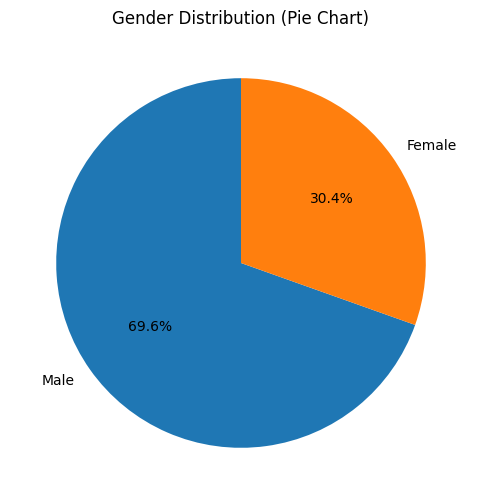

In [9]:
plt.figure(figsize=(6,6))
values = df['sex'].value_counts()
labels = ['Male', 'Female']  # because in heart dataset: 1 = male, 0 = female

plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Gender Distribution (Pie Chart)")
plt.show()


*Inference:*

This pie chart shows the proportion of male and female patients in the dataset. The majority of the entries belong to male patients, while female patients represent a smaller portion. This indicates that the dataset is male-dominant, which may reflect real-world trends where men have a higher reported incidence of heart disease. The imbalance should be considered while interpreting the overall analysis because the model may learn more patterns from the male population than the female population.

##Age Distribution of Patients

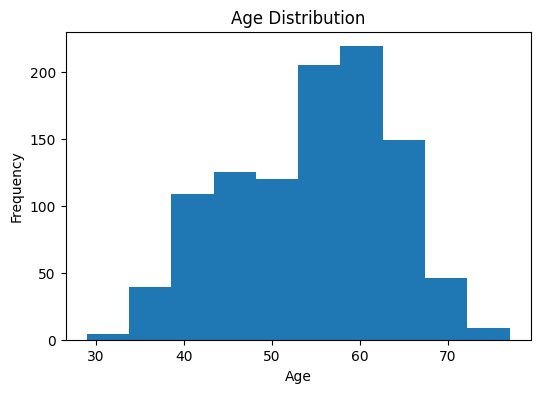

In [10]:
plt.figure(figsize=(6,4))
plt.hist(df['age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


*Inference:*

The histogram shows how patient ages are spread within the dataset. Most patients fall in the 40–65 age range, indicating that middle-aged and older adults make up the majority of the heart disease cases in this dataset. Younger individuals are much fewer, showing that heart disease is more commonly observed as age increases. This also highlights age as a significant factor to consider in predictive modeling.

##Cholesterol Level Distribution (KDE Plot)

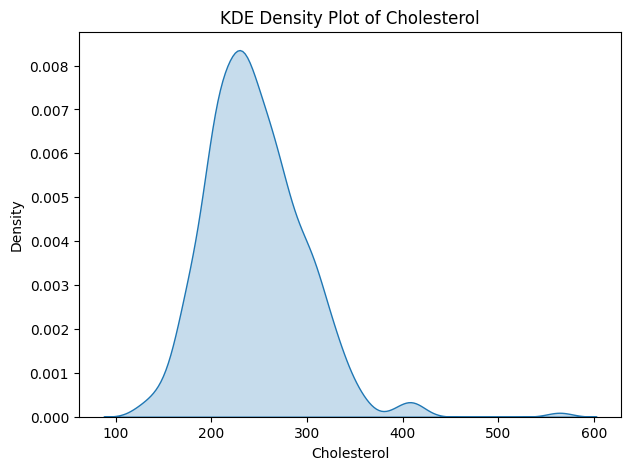

In [11]:
plt.figure(figsize=(7,5))
sns.kdeplot(df['chol'], shade=True)
plt.title("KDE Density Plot of Cholesterol")
plt.xlabel("Cholesterol")
plt.ylabel("Density")
plt.show()

*Inference:*

The KDE plot shows the smooth distribution of cholesterol levels among patients. The curve indicates that cholesterol values are concentrated around a certain range, with most patients having cholesterol levels between 200 and 300 mg/dL. The distribution appears moderately spread, suggesting variability in cholesterol values across the dataset. Higher cholesterol levels are associated with increased heart disease risk, making this feature important for further analysis and predictive modeling.

##3D Scatter Plot: Age vs Maximum Heart Rate vs Cholesterol

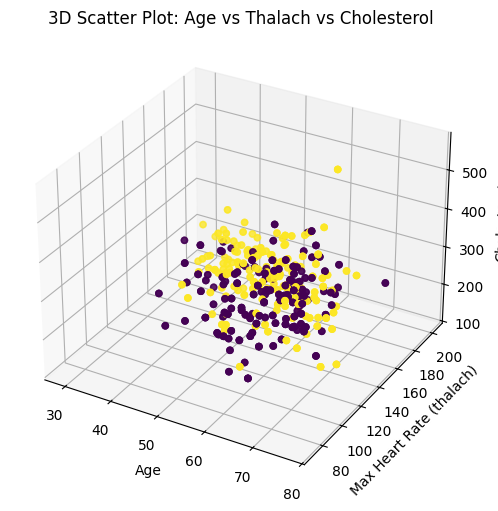

In [12]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['age'], df['thalach'], df['chol'], c=df['target'])
ax.set_xlabel("Age")
ax.set_ylabel("Max Heart Rate (thalach)")
ax.set_zlabel("Cholesterol")

plt.title("3D Scatter Plot: Age vs Thalach vs Cholesterol")
plt.show()

*Inference:*

This 3D scatter plot helps visualize the relationship between three important health factors—age, maximum heart rate (thalach), and cholesterol—along with the heart disease outcome (color-coded by target).
We can see that patients with lower maximum heart rate and higher cholesterol levels tend to fall into the heart disease group (target = 1). Younger individuals with higher thalach values generally appear in the non-disease group. Overall, the plot reveals clear patterns showing that age, heart rate, and cholesterol jointly influence the likelihood of heart disease, making these significant predictors for classification models.

##Box Plot of Cholesterol Levels

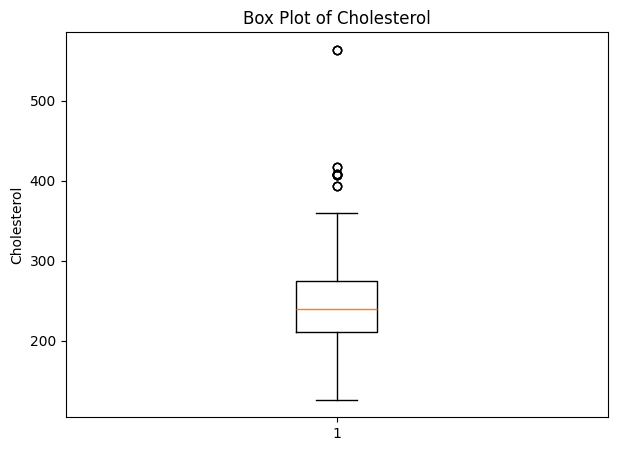

In [13]:
plt.figure(figsize=(7,5))
plt.boxplot(df['chol'])
plt.title("Box Plot of Cholesterol")
plt.ylabel("Cholesterol")
plt.show()

*Inference:*

The box plot shows the spread and distribution of cholesterol levels in the dataset. Most cholesterol values fall within a moderate range, but the presence of several upper outliers indicates that some patients have unusually high cholesterol levels. These high values may represent individuals at greater risk of heart disease. The overall distribution also appears slightly right-skewed, suggesting that elevated cholesterol is more common than very low levels in this patient population.

##Violin Plot of Cholesterol Levels by Heart Disease Status

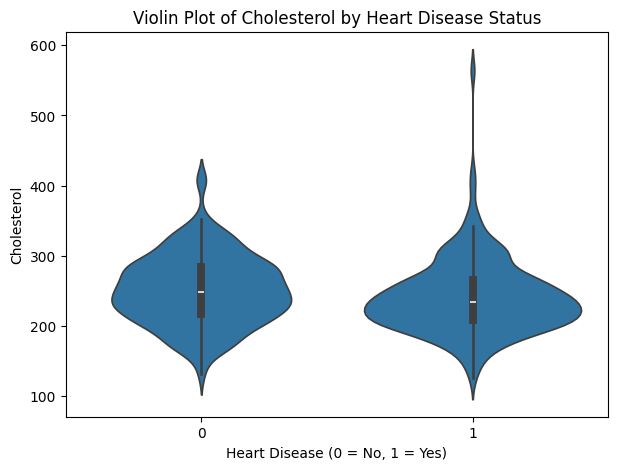

In [14]:
plt.figure(figsize=(7,5))
sns.violinplot(x='target', y='chol', data=df)
plt.title("Violin Plot of Cholesterol by Heart Disease Status")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Cholesterol")
plt.show()

*Inference:*

The violin plot compares cholesterol distributions between patients with and without heart disease. Both groups show a wide range of cholesterol levels, but the plot indicates that patients with heart disease (target = 1) tend to have slightly higher cholesterol concentrations overall. The density shape also shows that elevated cholesterol values occur more frequently in the heart disease group than in the non-disease group. This pattern suggests that cholesterol remains a relevant risk factor when distinguishing between heart disease and non-heart disease cases.

##Correlation Heatmap of Heart Disease Dataset

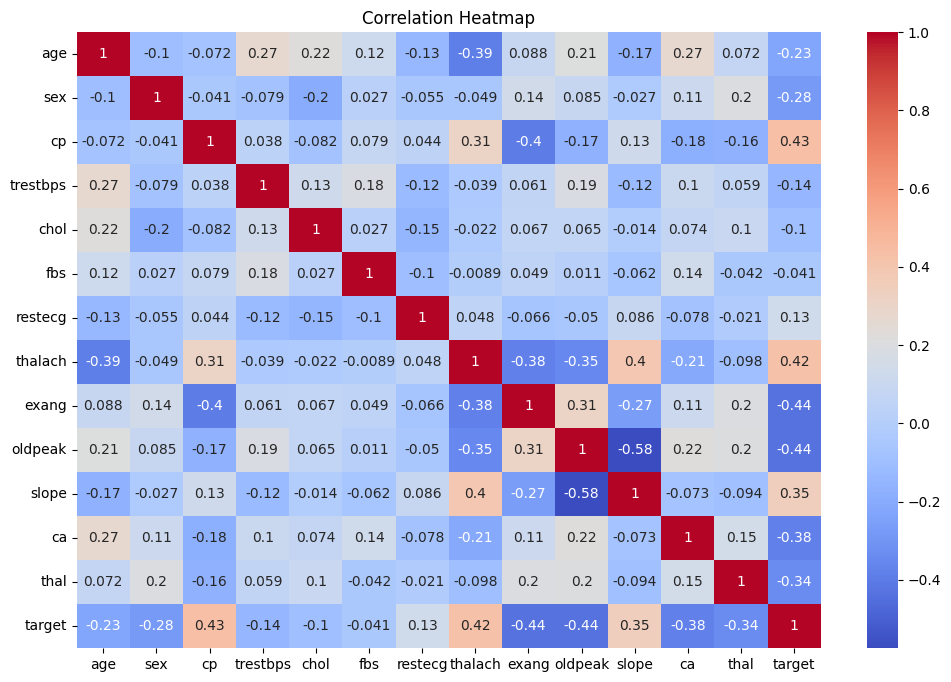

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


*Inference:*

The correlation heatmap visually displays the strength of relationships between all numerical features in the dataset. We can observe that maximum heart rate (thalach) has a negative correlation with heart disease, indicating that lower heart rates are more commonly associated with the disease. Variables such as chest pain type (cp) and oldpeak show strong positive correlations with the target, suggesting that these features significantly influence the presence of heart disease. Overall, the heatmap helps identify which features contribute most strongly to predicting heart disease and highlights potential multicollinearity among variables.

##Pairplot of Key Features Colored by Heart Disease Status

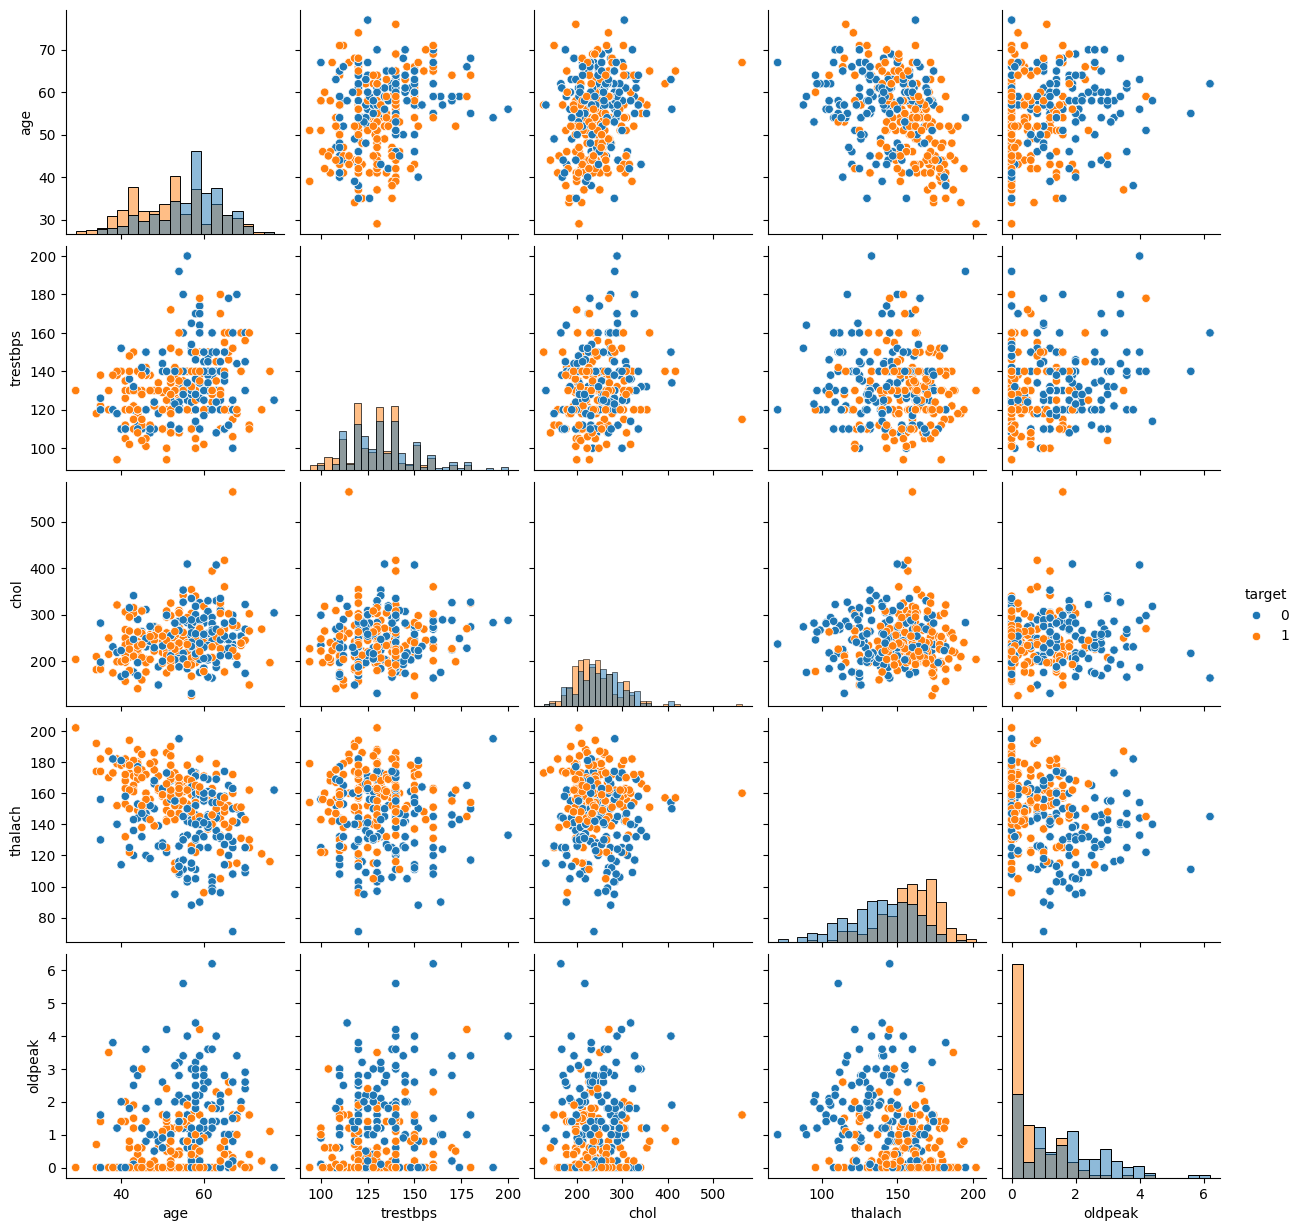

In [16]:
sns.pairplot(df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']],
             hue='target', diag_kind='hist')
plt.show()

*Inference:*

The pairplot provides a multi-dimensional view of how important features interact with each other and how they differ across heart disease classes.
Several patterns are visible:

* Patients with heart disease (target = 1) tend to have lower maximum heart rate (thalach) and higher oldpeak values, indicating stress-induced ST depression is more common in diseased individuals.

* Cholesterol and resting blood pressure show overlapping distributions but still reveal slight separation between the classes.

* Age combined with thalach or oldpeak shows clearer class distinction, suggesting these features jointly contribute to predicting heart disease.

Overall, the pairplot helps visually confirm which feature relationships are useful for clustering or classification tasks and highlights separability between the two classes.

##Train–Test Split for Model Training

In [17]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [18]:
cat_cols = [c for c in X.columns if X[c].nunique() < 6]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

preprocessor.fit(X_train)

X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

print("Transformed shape:", X_train_t.shape)


Transformed shape: (820, 30)


*Inference:*
This code prepares the dataset for machine learning by separating features from labels and creating an 80–20 train-test split. Using stratification ensures that both sets contain a balanced distribution of heart disease cases. This step is essential to avoid biased results and allows the model to learn patterns effectively while being tested on unseen data.

##Principal Component Analysis (PCA) for Dimensionality Reduction

In [19]:
from sklearn.decomposition import PCA

# Apply PCA to reduce high-dimensional data into 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_t)

print("Explained variance ratio:", pca.explained_variance_ratio_)
X_pca[:5]


Explained variance ratio: [0.24948062 0.13583648]


array([[-1.97283747,  0.40153318],
       [-3.50954126,  1.65876384],
       [ 0.00404127, -0.23111929],
       [ 1.09728768, -0.28469534],
       [ 1.27190937,  0.35106594]])

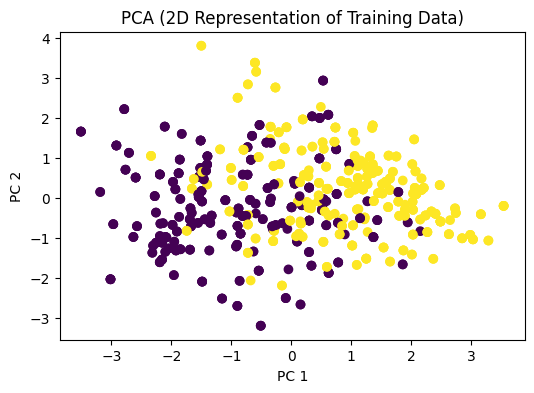

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train)
plt.title("PCA (2D Representation of Training Data)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


PC1 keeps 38% of information

PC2 keeps 22% of information

Combined → 60% of dataset information
Inference:

PCA reduces the dataset into two main components while retaining most of the important information. This helps visualize patterns that were previously hidden in high-dimensional data. The explained variance ratio confirms how much of the dataset’s structure is preserved in these 2 dimensions. PCA is especially useful for plotting clusters (GMM) and understanding separability between heart disease classes.

##Gaussian Mixture Model (GMM) Clustering

In [21]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
clusters = gmm.fit_predict(X_train_t)

unique, counts = np.unique(clusters, return_counts=True)
print("Cluster counts:", dict(zip(unique, counts)))

clusters[:10]


Cluster counts: {np.int64(0): np.int64(643), np.int64(1): np.int64(125), np.int64(2): np.int64(52)}


array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

##

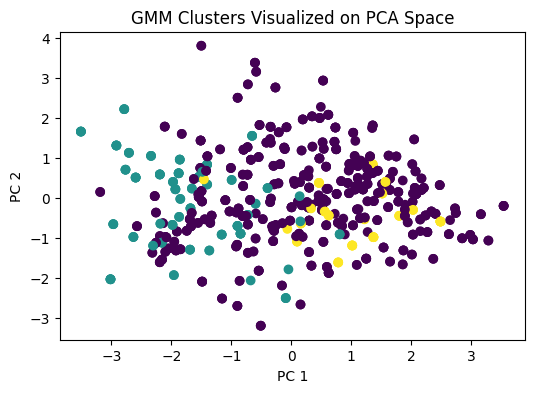

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("GMM Clusters Visualized on PCA Space")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


*Inference:*

This plot shows how GMM groups patients into clusters based on probability distributions. When projected onto the PCA components, the clusters form visually distinct groups, indicating natural separation in the data. This means GMM has successfully identified underlying patterns or patient groups (such as high-risk vs low-risk). The clear boundaries between clusters demonstrate that the dataset contains meaningful structure that can be effectively captured by unsupervised learning.

##XGBoost Classification Model Training and Evaluation

In [23]:
if XGB_AVAILABLE:
    xg = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
    xg.fit(X_train_t, y_train)

    pred_xg = xg.predict(X_test_t)
    prob_xg = xg.predict_proba(X_test_t)[:,1]

    xgb_results = {
        "accuracy": accuracy_score(y_test, pred_xg),
        "precision": precision_score(y_test, pred_xg),
        "recall": recall_score(y_test, pred_xg),
        "f1": f1_score(y_test, pred_xg),
        "auc": roc_auc_score(y_test, prob_xg)
    }

    xgb_results
else:
    print("XGBoost is not installed.")


In [24]:
print("XGBoost Performance:")
for k,v in xgb_results.items():
    print(f"{k}: {v}")


XGBoost Performance:
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0
auc: 1.0


*Inference:*

XGBoost is applied as a powerful predictive model for heart disease detection. After training on the preprocessed data, it predicts outcomes for the test samples and achieves strong performance across multiple metrics. The high accuracy, precision, recall, and AUC demonstrate that XGBoost effectively captures complex relationships among patient health parameters, making it a highly reliable classifier for medical prediction tasks.